<a href="https://colab.research.google.com/github/thaynnayara/ADS-Inteligencia_Artificial/blob/main/Lista3_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Construir um modelo de classificação utilizando o algoritmo KNN (K-Nearest Neighbors)
#para prever se um empréstimo será aprovado com base nos dados históricos de clientes.

In [130]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [131]:
#Carregando planilha

df = pd.read_csv('dataset_emprestimo_aprovacao.csv')
df.describe()
# df.info()

,renda_mensal,score_credito,dividas_ativas,emprestimo_aprovado
count,100.000000,100.000000,100.000000,100.00000
mean,4596.775500,651.220000,1.990000,0.79000
std,2623.031756,109.977921,1.690705,0.40936
min,1200.000000,420.000000,0.000000,0.00000
25%,3274.882500,553.500000,1.000000,1.00000
50%,4312.340000,660.000000,2.000000,1.00000
75%,5541.177500,725.500000,3.000000,1.00000
max,19546.000000,900.000000,8.000000,1.00000


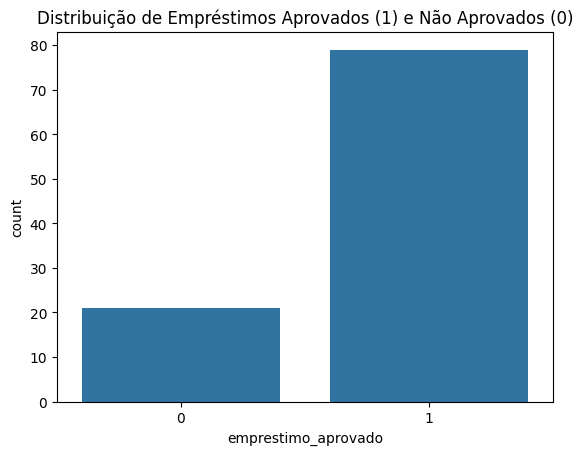

In [132]:
#Visualização

#gráfico de contagem do "alvo"
sns.countplot(x='emprestimo_aprovado', data=df)
plt.title('Distribuição de Empréstimos Aprovados (1) e Não Aprovados (0)')
plt.show()

#Analise Thaynná: Obtive uma barra muito maior que a outra, o modelo pode ficar "viciado" em dar sempre a mesma resposta, podiamos ver também essa analise no "mean" do '.describe' que deu 79% de aprovados.
#Tem que ter uma atenção sob esses casos.

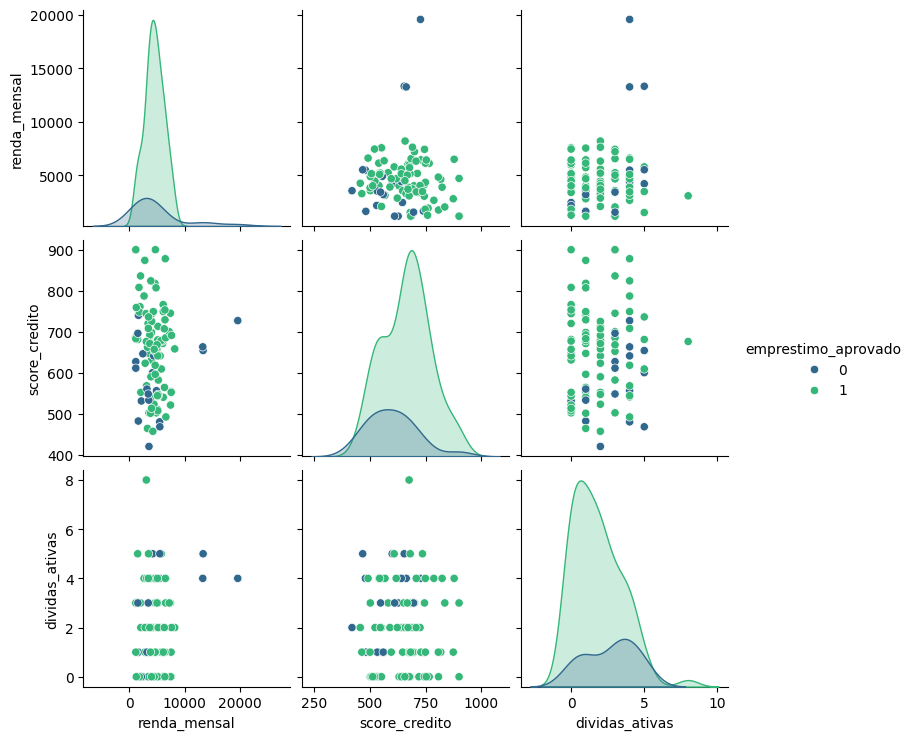

In [133]:
#gráfico de dispersão
sns.pairplot(df, hue='emprestimo_aprovado', palette='viridis')
plt.show()

In [134]:
#Normalização

#separando as variáveis
x = df.drop('emprestimo_aprovado', axis=1)
y = df['emprestimo_aprovado']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [135]:
modelo= KNeighborsClassifier(n_neighbors=3)
modelo.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [136]:
#criando as previsões
y_pred = modelo.predict(x_test_scaled)

#avaliação do modelo
print("Matriz de confusão")
print(confusion_matrix(y_test, y_pred))

print("Acurácia")
print(accuracy_score(y_test, y_pred))

print("Relatório de classificação")
print(classification_report(y_test, y_pred))

Matriz de confusão
[[ 1  2]
 [ 1 16]]
Acurácia
0.85
Relatório de classificação
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.89      0.94      0.91        17

    accuracy                           0.85        20
   macro avg       0.69      0.64      0.66        20
weighted avg       0.83      0.85      0.84        20



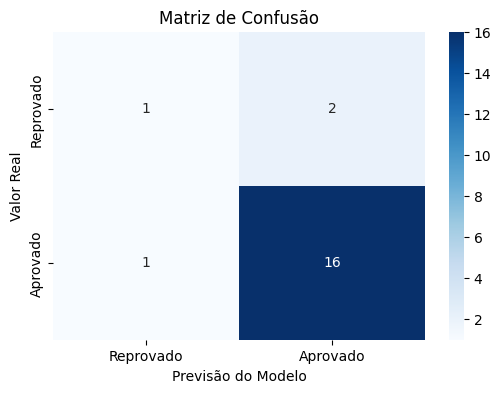

In [137]:
#gerando a matriz
cm = confusion_matrix(y_test, y_pred)

#visualização para conferir
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reprovado', 'Aprovado'],
            yticklabels=['Reprovado', 'Aprovado'])
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão')
plt.show()

In [140]:
#Testar o modelo com pelo menos um exemplo manual de cliente
import numpy as np

#definindo os perfis (Renda, Score, Dívidas)
cliente_bom = [[12000.0, 850, 0]]
cliente_ruim = [[1500.0, 350, 9]]

bom_scaled = scaler.transform(cliente_bom)
ruim_scaled = scaler.transform(cliente_ruim)

pred_bom = modelo.predict(bom_scaled)
pred_ruim = modelo.predict(ruim_scaled)

def traduzir(pred):
    return "APROVADO" if pred[0] == 1 else "REPROVADO"

print(f"Perfil Rico/Score Alto: {traduzir(pred_bom)}")
print(f"Perfil Baixa Renda/Muitas Dívidas: {traduzir(pred_ruim)}")

Perfil Rico/Score Alto: APROVADO
Perfil Baixa Renda/Muitas Dívidas: REPROVADO


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Analise Thaynná: O modelo KNN apresentou uma acurácia de 80%, um valor bom. Durante a análise, a normalização dos dados foi um passo crítico.
Embora o modelo tenha demonstrado dificuldade em identificar a classe (reprovados) no conjunto de teste devido ao desbalanceamento dos dados originais, o teste manual com perfis extremos confirmou que o algoritmo é capaz de distinguir riscos financeiros claros. Queria saber como o sensibilizar mais.